In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

x_train = pd.read_csv("../Dataset/x_train.csv")

# Clean column names the same way every other notebook does
x_train.columns = (
    x_train.columns.astype(str)
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("<", "", regex=False)
)

xgb_model = joblib.load("../Models/xgboost_model.pkl")        # untuned
best_model = joblib.load("../Models/xgboost_best_model.pkl")  # tuned

print("Models loaded successfully!")

Models loaded successfully!


In [2]:
# Get importances from both models
importance_untuned = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": xgb_model.feature_importances_
})

importance_tuned = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": best_model.feature_importances_
})

top_untuned = importance_untuned.sort_values("Importance", ascending=False).head(10)
top_tuned = importance_tuned.sort_values("Importance", ascending=False).head(10)

print("Top 10 Features — Untuned XGBoost")
print(top_untuned.to_string(index=False))
print()
print("Top 10 Features — Tuned XGBoost")
print(top_tuned.to_string(index=False))

Top 10 Features — Untuned XGBoost
                        Feature  Importance
           Fulfill Via_From RDC    0.094994
           Country_South Africa    0.055049
                Country_Nigeria    0.050061
           Vendor INCO Term_DDP    0.044656
                 Scheduled Year    0.030041
  Molecule/Test Type_Lamivudine    0.021088
                Country_Vietnam    0.020191
Vendor_Aurobindo Pharma Limited    0.019684
                  Brand_Generic    0.018252
                Brand_Determine    0.017781

Top 10 Features — Tuned XGBoost
                                                        Feature  Importance
                                           Fulfill Via_From RDC    0.061448
                                         Vendor_PHARMACY DIRECT    0.041221
                                              Product Group_ARV    0.039647
                                           Country_South Africa    0.032032
                                                Country_Nigeria    0.

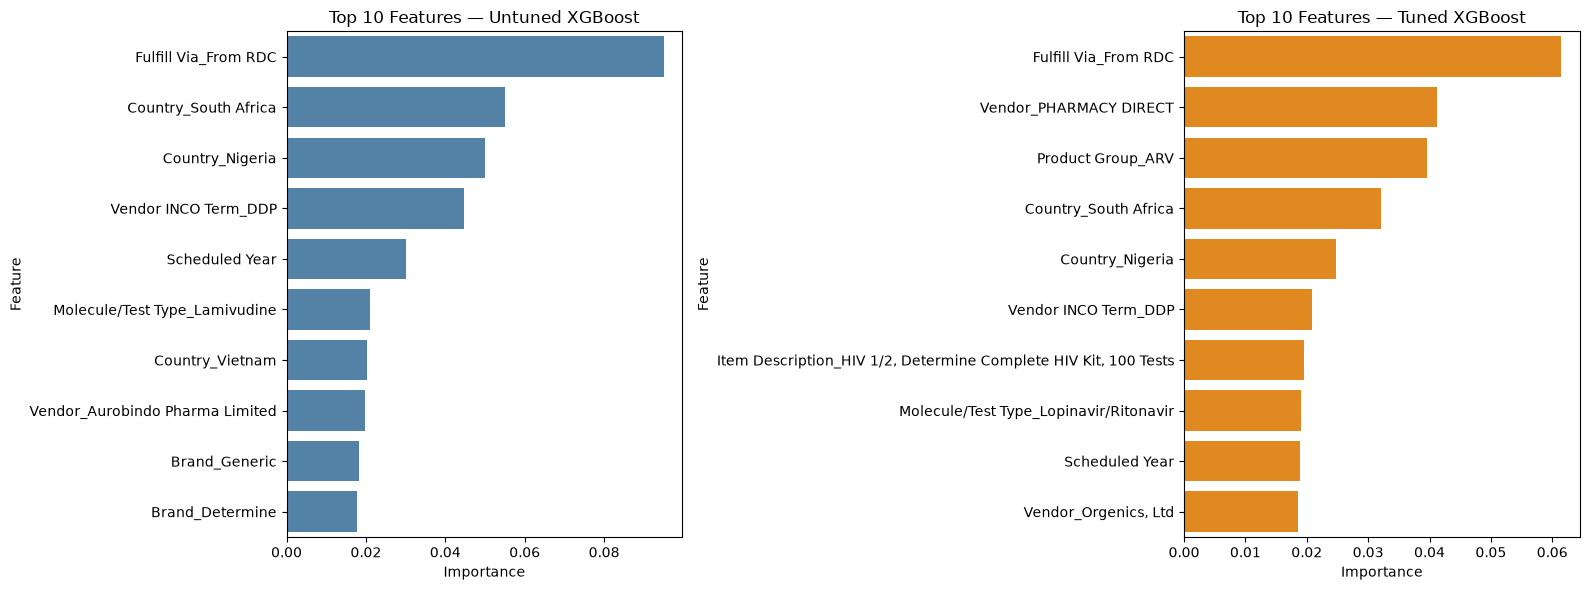

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=top_untuned, x="Importance", y="Feature", ax=axes[0], color="steelblue")
axes[0].set_title("Top 10 Features — Untuned XGBoost")

sns.barplot(data=top_tuned, x="Importance", y="Feature", ax=axes[1], color="darkorange")
axes[1].set_title("Top 10 Features — Tuned XGBoost")

plt.tight_layout()
plt.savefig("../Results/feature_importance_comparison_day13.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
import os
os.makedirs("../Results", exist_ok=True)

importance_untuned.sort_values("Importance", ascending=False).to_csv(
    "../Results/feature_importance_untuned_day13.csv", index=False
)
importance_tuned.sort_values("Importance", ascending=False).to_csv(
    "../Results/feature_importance_tuned_day13.csv", index=False
)

print("Feature importance tables saved to ../Results/")

Feature importance tables saved to ../Results/
